Script per provare la classe definita per l'analisi e la valutazione dei diversi keygenes.   


# Packages

In [1]:
import pandas as pd 

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning) # Nasconde i FutureWarning

# Per aggiungere un path per dei pacchetti selfmade
import sys
sys.path.append('__HandmadePackages__')

# Classe per agevolare la valutazione della performance di un subset di keygenes
from EvaluatePipeline import Evaluate

# Funzioni selfmade per preprocessing
import preprocessing
from evaluate_performance import performance_binary, performance_multiclass
# Classe selfmade per creare report LaTeX
#from LaTeX import LaTeX, knit

# Manage the data

## Import the data

In [2]:
#df_train = pd.read_csv("/Users/mattia/Desktop/Università/Magistrale/Tesi/Python TMM only for exploration/Data/GBM_DEGS_normalized_counts_train.csv")
#df_train = pd.read_csv("/Users/mattia/Desktop/Università/Magistrale/Tesi/Python TMM only for exploration/Data/GBM_DEGREE_normalized_counts_train.csv")
#df_train = pd.read_csv("/Users/mattia/Desktop/Università/Dottorato/TEPs HC vs GBM/Train_GSE68086_Test_GSE156902/Data Product/normalizedcounts_trained_onGSE68086_GBM_HC_BETWEENNESS.csv")
#df_train = pd.read_csv("/Users/mattia/Desktop/Università/Magistrale/Tesi/Python TMM only for exploration/Data/GBM_CLOSENESS_normalized_counts_train.csv")
#df_train = pd.read_csv("/Users/mattia/Desktop/Università/Magistrale/Tesi/Python TMM only for exploration/Data/GBM_CLOSENESS_last5_normalized_counts_train.csv")
#df_train = pd.read_csv("/Users/mattia/Desktop/Università/Magistrale/Tesi/Python TMM only for exploration/Data/GBM_EIGEN_normalized_counts_train.csv")
#df_train = pd.read_csv("/Users/mattia/Desktop/Università/Magistrale/Tesi/Python TMM only for exploration/Data/GBM_CLUSTER_normalized_counts_train.csv")

df_train = pd.read_csv("train_degs_brca_183635.csv")

print(f"df_train shape: {df_train.shape}")

#df_test1 = pd.read_csv("/Users/mattia/Desktop/Università/Dottorato/TEPs HC vs GBM/Train_GSE68086_Test_GSE156902/Data Product/testdata_normalized_GSE156902_GBM_HC.csv")
df_test1 = pd.read_csv("test_degs_brca_183635.csv")

print(f"df_test1 shape: {df_test1.shape}")

df_train shape: (94, 2924)
df_test1 shape: (474, 2924)


In [3]:
df_train.head()

,ENSG00000000419,ENSG00000000938,ENSG00000001631,ENSG00000002822,ENSG00000003436,ENSG00000003756,ENSG00000004455,ENSG00000004534,ENSG00000004766,ENSG00000004779,...,ENSG00000257267,ENSG00000257923,ENSG00000258890,ENSG00000259719,ENSG00000261253,ENSG00000265148,ENSG00000266714,ENSG00000268555,ENSG00000272888,cancer_binary
0,3.564805,5.473822,4.343858,1.748744,7.703946,4.062795,3.626089,5.522985,3.684876,4.794528,...,8.025842,8.429791,3.684876,7.566103,6.581828,3.433826,0.644677,2.996788,-0.334369,0
1,2.188224,4.856539,2.359487,1.993857,9.113012,2.438052,3.100726,4.501581,-0.898678,3.517363,...,8.088763,8.507272,4.004159,8.198625,6.734982,3.896981,1.885881,6.535020,-0.898678,0
2,2.422728,3.013670,4.147883,0.527223,8.399664,3.348700,2.958763,4.331978,-0.898678,3.066563,...,8.372352,8.517144,2.250554,8.045089,7.134167,4.821852,0.188478,7.422390,-0.898678,0
3,3.058296,2.148325,3.492167,3.492167,8.440235,4.692944,2.434913,4.175665,2.148325,3.058296,...,7.954080,7.418015,-0.898678,7.234207,7.252757,2.673897,-0.898678,7.289156,0.595089,0
4,1.944623,4.215196,1.456827,2.764315,8.691939,5.494343,2.981594,4.717216,0.714320,3.047311,...,7.565117,8.908549,4.186316,7.744218,5.574541,3.931758,2.197108,7.055891,0.347778,0


In [4]:
df_test1.head()

,ENSG00000000419,ENSG00000000938,ENSG00000001631,ENSG00000002822,ENSG00000003436,ENSG00000003756,ENSG00000004455,ENSG00000004534,ENSG00000004766,ENSG00000004779,...,ENSG00000257267,ENSG00000257923,ENSG00000258890,ENSG00000259719,ENSG00000261253,ENSG00000265148,ENSG00000266714,ENSG00000268555,ENSG00000272888,cancer_binary
0,1.702293,3.540608,3.744315,0.067991,8.219002,4.004370,2.852966,0.949068,2.048427,2.448928,...,7.534991,8.902104,2.938479,7.558817,6.838356,5.993142,1.885716,6.781633,4.530288,1
1,5.599063,7.663536,5.844884,5.366949,7.496143,5.783317,5.651693,7.062997,3.044705,6.470718,...,6.670976,7.030244,5.783317,5.932572,5.581085,5.599063,6.214981,5.387784,5.280465,1
2,5.762092,8.264602,5.090966,4.408436,6.370105,6.354011,5.203026,6.550409,5.465207,6.954308,...,6.253484,7.893573,5.166631,6.447988,6.164005,6.370105,7.125250,5.434924,5.090966,1
3,6.922456,5.819607,5.271555,4.773664,6.705855,3.920337,4.959382,7.916209,3.729172,8.307035,...,6.435311,5.770793,5.528050,4.869509,4.616785,4.310185,7.100903,4.560457,4.310185,1
4,6.191786,6.554855,5.314166,5.523038,7.102269,3.906277,4.930192,5.768329,3.136795,7.355300,...,7.421994,6.096996,5.705460,6.364506,4.647618,5.134916,3.370885,5.617130,5.166380,1


In [5]:
da_rimuovere = pd.read_csv("train_intersection_brca_183635.csv")

In [11]:
# =========================
# Packages
# =========================
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Selfmade packages path
import sys
sys.path.append('__HandmadePackages__')

# Funzioni selfmade
from evaluate_performance import performance_binary  # <-- usa la tua
# (Evaluate, preprocessing ecc. non servono qui direttamente, li lasci se ti servono altrove)

# Modelli
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import roc_auc_score


# =========================
# Config
# =========================
RANDOM_SEED = 42
N_REPEATS = 100
N_GENES = 20
POS_LABEL = 1  # classe positiva per AUC (y==1)

rng = np.random.default_rng(RANDOM_SEED)


# =========================
# Load data
# =========================
df_train = pd.read_csv("train_degs_brca_183635.csv")
df_test1 = pd.read_csv("test_degs_brca_183635.csv")

print(f"df_train shape: {df_train.shape}")
print(f"df_test1 shape: {df_test1.shape}")

# Split X/y
X_train_full = df_train.iloc[:, :-1]
y_train = df_train.iloc[:, -1]

X_test_full = df_test1.iloc[:, :-1]
y_test = df_test1.iloc[:, -1]


# =========================
# Remove genes from intersection file
# (stessa struttura: colonne=geni, ultima colonna=label)
# =========================
da_rimuovere = pd.read_csv("train_intersection_brca_183635.csv")

# geni da rimuovere = nomi colonne tranne l'ultima
remove_genes = da_rimuovere.columns[:-1].tolist()
remove_set = set(remove_genes)

# rimuovi dai dataframes (solo se presenti)
to_drop_train = sorted(list(set(X_train_full.columns).intersection(remove_set)))
to_drop_test  = sorted(list(set(X_test_full.columns).intersection(remove_set)))

print(f"Geni da rimuovere (presenti nel train): {len(to_drop_train)}")
print(f"Geni da rimuovere (presenti nel test):  {len(to_drop_test)}")

X_train_full = X_train_full.drop(columns=to_drop_train, errors="ignore")
X_test_full  = X_test_full.drop(columns=to_drop_test, errors="ignore")

# tieni solo colonne comuni (importantissimo)
common_cols = sorted(list(set(X_train_full.columns).intersection(set(X_test_full.columns))))
X_train_full = X_train_full[common_cols]
X_test_full  = X_test_full[common_cols]

gene_cols = common_cols
print(f"Geni rimanenti dopo rimozione + intersezione train/test: {len(gene_cols)}")

if len(gene_cols) < N_GENES:
    raise ValueError(f"Dopo la rimozione restano {len(gene_cols)} geni, ma ne servono {N_GENES}.")


# =========================
# Helper: score continuo per AUC
# =========================
def get_y_score(model, X):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        return proba[:, 1]
    elif hasattr(model, "decision_function"):
        return model.decision_function(X)
    else:
        return None


# =========================
# Modelli (rigenerati ad ogni repeat)
# =========================
def make_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=2000),
        # se vuoi AUC via proba anche per SVC: probability=True (più lento)
        "SVC": SVC(kernel="rbf", C=1.0, gamma="scale", probability=False),
        "Random Forest": RandomForestClassifier(n_estimators=500, max_depth=None, random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(learning_rate=0.05, n_estimators=500, max_depth=10, random_state=42),
        "XGBoost": XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=10,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss"
        ),
        "CatBoost": CatBoostClassifier(
            iterations=500,
            learning_rate=0.05,
            depth=4,
            verbose=False,
            random_state=42
        )
    }


# =========================
# Loop: 100 subset da 29 geni + metriche
# =========================
all_gene_sets = []   # 100 liste di 29 geni
rows = []            # metriche per ogni (repeat, modello)

for rep in range(N_REPEATS):
    selected_genes = rng.choice(gene_cols, size=N_GENES, replace=False).tolist()
    all_gene_sets.append(selected_genes)

    X_train = X_train_full[selected_genes]
    X_test = X_test_full[selected_genes]

    models = make_models()

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        perf = performance_binary(
            test_y=y_test,
            predizioni=y_pred,
            verbose=False,
            labels_float={"0": "Cancer", "1": "Healthy"}
        )

        # --- se le chiavi della tua perf sono diverse, modifica qui ---
        df_cm_metrics = perf["df_report_cm"]  
        pos_name = "Cancer"  

        acc  = df_cm_metrics.loc[pos_name, "Accuracy"]
        prec = df_cm_metrics.loc[pos_name, "Precision"]
        rec  = df_cm_metrics.loc[pos_name, "Recall"]
        f1   = df_cm_metrics.loc[pos_name, "F1-Score"]


        # AUC (se possibile)
        y_score = get_y_score(model, X_test)
        auc = roc_auc_score(y_test, y_score) if y_score is not None else np.nan

        rows.append({
            "repeat": rep,
            "model": model_name,
            "accuracy": float(acc) if acc is not None else np.nan,
            "precision": float(prec) if prec is not None else np.nan,
            "recall": float(rec) if rec is not None else np.nan,
            "f1": float(f1) if f1 is not None else np.nan,
            "auc": float(auc) if auc is not None else np.nan,
        })


# =========================
# Risultati: mean ± std
# =========================
results_df = pd.DataFrame(rows)

def mean_std_str(s):
    return f"{s.mean():.4f} ± {s.std(ddof=1):.4f}"

metrics = ["accuracy", "precision", "recall", "f1", "auc"]
pretty_df = pd.DataFrame({
    m: results_df.groupby("model")[m].apply(mean_std_str)
    for m in metrics
})

print("\n===== RISULTATI FINALI (mean ± std su 100 subset da 29 geni) =====")
print(pretty_df)

df_train shape: (94, 2924)
df_test1 shape: (474, 2924)
Geni da rimuovere (presenti nel train): 18
Geni da rimuovere (presenti nel test):  18
Geni rimanenti dopo rimozione + intersezione train/test: 2905

===== RISULTATI FINALI (mean ± std su 100 subset da 29 geni) =====
                            accuracy        precision           recall  \
model                                                                    
CatBoost             0.5044 ± 0.0758  0.2584 ± 0.0260  0.9360 ± 0.0497   
Gradient Boosting    0.4977 ± 0.1247  0.2496 ± 0.0435  0.8520 ± 0.0856   
Logistic Regression  0.5285 ± 0.0654  0.2671 ± 0.0258  0.9307 ± 0.0487   
Random Forest        0.5196 ± 0.0545  0.2641 ± 0.0183  0.9436 ± 0.0445   
SVC                  0.4911 ± 0.0688  0.2547 ± 0.0213  0.9529 ± 0.0405   
XGBoost              0.5562 ± 0.0593  0.2760 ± 0.0243  0.9067 ± 0.0567   

                                  f1              auc  
model                                                  
CatBoost             0.4

In [ ]:
# ============================================================
# FULL SCRIPT
# - 100 random gene subsets -> empirical distribution of metrics
# - 95th percentile (BLUE line)
# - manual "real" values per classifier (RED line) via a table you fill
# ============================================================

# =========================
# Packages
# =========================
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import sys
sys.path.append('__HandmadePackages__')

from evaluate_performance import performance_binary  # <-- la tua

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt


# =========================
# Config
# =========================
RANDOM_SEED = 42
N_REPEATS = 100
N_GENES = 29
rng = np.random.default_rng(RANDOM_SEED)

metrics = ["accuracy", "precision", "recall", "f1", "auc"]


# =========================
# Load data
# =========================
df_train = pd.read_csv("train_degs_gbm_156902.csv")
df_test1 = pd.read_csv("test_degs_gbm_156902.csv")

print(f"df_train shape: {df_train.shape}")
print(f"df_test1 shape: {df_test1.shape}")

# Split X/y
X_train_full = df_train.iloc[:, :-1]
y_train = df_train.iloc[:, -1]

X_test_full = df_test1.iloc[:, :-1]
y_test = df_test1.iloc[:, -1]


# =========================
# Remove genes from intersection file
# =========================
da_rimuovere = pd.read_csv("test_intersection_gbm_156902.csv")

remove_genes = da_rimuovere.columns[:-1].tolist()
remove_set = set(remove_genes)

to_drop_train = sorted(list(set(X_train_full.columns).intersection(remove_set)))
to_drop_test  = sorted(list(set(X_test_full.columns).intersection(remove_set)))

print(f"Geni da rimuovere (presenti nel train): {len(to_drop_train)}")
print(f"Geni da rimuovere (presenti nel test):  {len(to_drop_test)}")

X_train_full = X_train_full.drop(columns=to_drop_train, errors="ignore")
X_test_full  = X_test_full.drop(columns=to_drop_test, errors="ignore")

# tieni solo colonne comuni
common_cols = sorted(list(set(X_train_full.columns).intersection(set(X_test_full.columns))))
X_train_full = X_train_full[common_cols]
X_test_full  = X_test_full[common_cols]

gene_cols = common_cols
print(f"Geni rimanenti dopo rimozione + intersezione train/test: {len(gene_cols)}")

if len(gene_cols) < N_GENES:
    raise ValueError(f"Dopo la rimozione restano {len(gene_cols)} geni, ma ne servono {N_GENES}.")


# =========================
# Helper: score continuo per AUC
# =========================
def get_y_score(model, X):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        return proba[:, 1]
    elif hasattr(model, "decision_function"):
        return model.decision_function(X)
    return None


# =========================
# Modelli
# =========================
def make_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=2000),
        "SVC": SVC(kernel="rbf", C=1.0, gamma="scale", probability=False),
        "Random Forest": RandomForestClassifier(n_estimators=500, max_depth=None, random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(learning_rate=0.05, n_estimators=500, max_depth=10, random_state=42),
        "XGBoost": XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=10,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss"
        ),
        "CatBoost": CatBoostClassifier(
            iterations=500,
            learning_rate=0.05,
            depth=4,
            verbose=False,
            random_state=42
        )
    }


# ============================================================
# 🔴 INSERISCI QUI I VALORI REALI DEI TUOI CLASSIFICATORI
# Compila con numeri reali; usa np.nan se non vuoi mettere una metrica
# ============================================================
real_scores_df = pd.DataFrame([
    {"model": "Logistic Regression", "accuracy": np.nan, "precision": np.nan, "recall": np.nan, "f1": np.nan, "auc": np.nan},
    {"model": "SVC",                 "accuracy": 0.9317, "precision": 0.9286, "recall": 0.7428, "f1": 0.8254, "auc": 0.914},
    {"model": "Random Forest",       "accuracy": np.nan, "precision": np.nan, "recall": np.nan, "f1": np.nan, "auc": np.nan},
    {"model": "Gradient Boosting",   "accuracy": np.nan, "precision": np.nan, "recall": np.nan, "f1": np.nan, "auc": np.nan},
    {"model": "XGBoost",             "accuracy": np.nan, "precision": np.nan, "recall": np.nan, "f1": np.nan, "auc": np.nan},
    {"model": "CatBoost",            "accuracy": np.nan, "precision": np.nan, "recall": np.nan, "f1": np.nan, "auc": np.nan},
])


# =========================
# Loop: 100 subset random + metriche
# =========================
rows = []

for rep in range(N_REPEATS):
    selected_genes = rng.choice(gene_cols, size=N_GENES, replace=False).tolist()

    X_train = X_train_full[selected_genes]
    X_test  = X_test_full[selected_genes]

    models = make_models()

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        perf = performance_binary(
            test_y=y_test,
            predizioni=y_pred,
            verbose=False,
            labels_float={"0": "Cancer", "1": "Healthy"}
        )

        # --- metriche dalla tua funzione ---
        df_cm_metrics = perf["df_report_cm"]
        pos_name = "Cancer"  # come nel tuo codice

        acc  = df_cm_metrics.loc[pos_name, "Accuracy"]
        prec = df_cm_metrics.loc[pos_name, "Precision"]
        rec  = df_cm_metrics.loc[pos_name, "Recall"]
        f1   = df_cm_metrics.loc[pos_name, "F1-Score"]

        # AUC (se possibile)
        y_score = get_y_score(model, X_test)
        try:
            auc = roc_auc_score(y_test, y_score) if y_score is not None else np.nan
        except Exception:
            auc = np.nan

        rows.append({
            "repeat": rep,
            "model": model_name,
            "accuracy": float(acc) if acc is not None else np.nan,
            "precision": float(prec) if prec is not None else np.nan,
            "recall": float(rec) if rec is not None else np.nan,
            "f1": float(f1) if f1 is not None else np.nan,
            "auc": float(auc) if auc is not None else np.nan,
        })

results_df = pd.DataFrame(rows)


# =========================
# Summary mean ± std
# =========================
def mean_std_str(s):
    return f"{s.mean():.4f} ± {s.std(ddof=1):.4f}"

pretty_df = pd.DataFrame({
    m: results_df.groupby("model")[m].apply(mean_std_str)
    for m in metrics
})

print("\n===== RISULTATI FINALI (mean ± std su 100 subset random) =====")
print(pretty_df)


# =========================
# 95th percentile per modello+metrica
# =========================
p95 = results_df.groupby("model")[metrics].quantile(0.95)

print("\n===== 95° percentile (distribuzione su 100 subset random) =====")
print(p95)


# =========================
# Sanity checks: real_scores_df vs models
# =========================
models_in_results = set(results_df["model"].unique())
models_in_real = set(real_scores_df["model"].unique())

missing_in_real = sorted(list(models_in_results - models_in_real))
extra_in_real = sorted(list(models_in_real - models_in_results))

if missing_in_real:
    print("\n[WARNING] Questi modelli sono nei risultati ma NON in real_scores_df:")
    print(missing_in_real)

if extra_in_real:
    print("\n[WARNING] Questi modelli sono in real_scores_df ma NON nei risultati:")
    print(extra_in_real)


# =========================
# Plot function
# =========================
def plot_null_with_thresholds(results_df, p95, real_scores_df, metrics, bins=15, save_dir=None):
    real_idx = real_scores_df.set_index("model")

    for model in results_df["model"].unique():
        df_m = results_df[results_df["model"] == model]

        for met in metrics:
            vals = df_m[met].dropna().values
            if len(vals) == 0:
                continue

            thr95 = float(p95.loc[model, met])

            plt.figure()
            plt.hist(vals, bins=bins)

            # BLUE: 95th percentile
            plt.axvline(thr95, color="blue", linewidth=2,
                        label="95th percentile (100 random subsets)")

            # RED: real value if provided
            real_val = np.nan
            if model in real_idx.index and met in real_idx.columns:
                real_val = real_idx.loc[model, met]

            if not pd.isna(real_val):
                plt.axvline(float(real_val), color="red", linewidth=2, label="Real value")

            plt.title(f"{model} — {met}")
            plt.xlabel(met)
            plt.ylabel("count")
            plt.legend()

            if save_dir is not None:
                import os
                os.makedirs(save_dir, exist_ok=True)
                safe_model = model.replace(" ", "_").replace("/", "_")
                plt.savefig(f"{save_dir}/{safe_model}_{met}.png", dpi=200, bbox_inches="tight")

            plt.show()


# =========================
# Run plots (set save_dir="plots" to save PNGs)
# =========================
plot_null_with_thresholds(
    results_df=results_df,
    p95=p95,
    real_scores_df=real_scores_df,
    metrics=metrics,
    bins=15,
    save_dir=None
)

In [11]:
# =========================
# Compact plots
# =========================

def plot_one_figure_per_metric(results_df, p95, real_scores_df, metrics, bins=15, save_dir=None):
    """
    Una figura per metrica.
    Dentro: 6 pannelli (2x3), uno per modello.
    Ogni pannello: istogramma distribuzione, linea blu p95, linea rossa valore reale (se presente).
    """
    import os
    real_idx = real_scores_df.set_index("model")
    model_order = list(results_df["model"].unique())

    n_models = len(model_order)
    ncols = 3
    nrows = int(np.ceil(n_models / ncols))

    for met in metrics:
        fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 3.6 * nrows), squeeze=False)
        axes = axes.ravel()

        for i, model in enumerate(model_order):
            ax = axes[i]
            df_m = results_df[results_df["model"] == model]
            vals = df_m[met].dropna().values

            if len(vals) == 0:
                ax.set_title(f"{model} — {met}\n(NO DATA)")
                ax.axis("off")
                continue

            thr95 = float(p95.loc[model, met])

            ax.hist(vals, bins=bins)
            ax.axvline(thr95, color="blue", linewidth=2, label="95th percentile")

            real_val = np.nan
            if model in real_idx.index and met in real_idx.columns:
                real_val = real_idx.loc[model, met]
            if not pd.isna(real_val):
                ax.axvline(float(real_val), color="red", linewidth=2, label="Real")

            ax.set_title(model)
            ax.set_xlabel(met)
            ax.set_ylabel("count")

            # legenda solo sul primo pannello per non affollare
            if i == 0:
                ax.legend()

        # spegni assi vuoti
        for j in range(n_models, len(axes)):
            axes[j].axis("off")

        fig.suptitle(f"Null distribution (100 random subsets) — {met}", y=1.02, fontsize=14)
        fig.tight_layout()

        if save_dir is not None:
            os.makedirs(save_dir, exist_ok=True)
            fig.savefig(f"{save_dir}/ALLMODELS_{met}.png", dpi=200, bbox_inches="tight")

        plt.show()


def plot_single_compact_figure_all_metrics(results_df, p95, real_scores_df, metrics, bins=15, save_path=None):
    """
    Una singola mega-figura: righe=metriche, colonne=modelli.
    (molto compatta ma può diventare piccola; utile per overview)
    """
    real_idx = real_scores_df.set_index("model")
    model_order = list(results_df["model"].unique())

    nrows = len(metrics)
    ncols = len(model_order)

    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.6 * nrows), squeeze=False)

    for r, met in enumerate(metrics):
        for c, model in enumerate(model_order):
            ax = axes[r, c]
            df_m = results_df[results_df["model"] == model]
            vals = df_m[met].dropna().values

            if len(vals) == 0:
                ax.axis("off")
                continue

            thr95 = float(p95.loc[model, met])
            ax.hist(vals, bins=bins)
            ax.axvline(thr95, color="blue", linewidth=2)

            real_val = np.nan
            if model in real_idx.index and met in real_idx.columns:
                real_val = real_idx.loc[model, met]
            if not pd.isna(real_val):
                ax.axvline(float(real_val), color="red", linewidth=2)

            if r == 0:
                ax.set_title(model, fontsize=10)
            if c == 0:
                ax.set_ylabel(f"{met}\ncount")
            else:
                ax.set_ylabel("")

            ax.set_xlabel("")

    fig.suptitle("Null distribution (100 random subsets) — blue=p95, red=real", y=1.01, fontsize=14)
    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=250, bbox_inches="tight")

    plt.show()

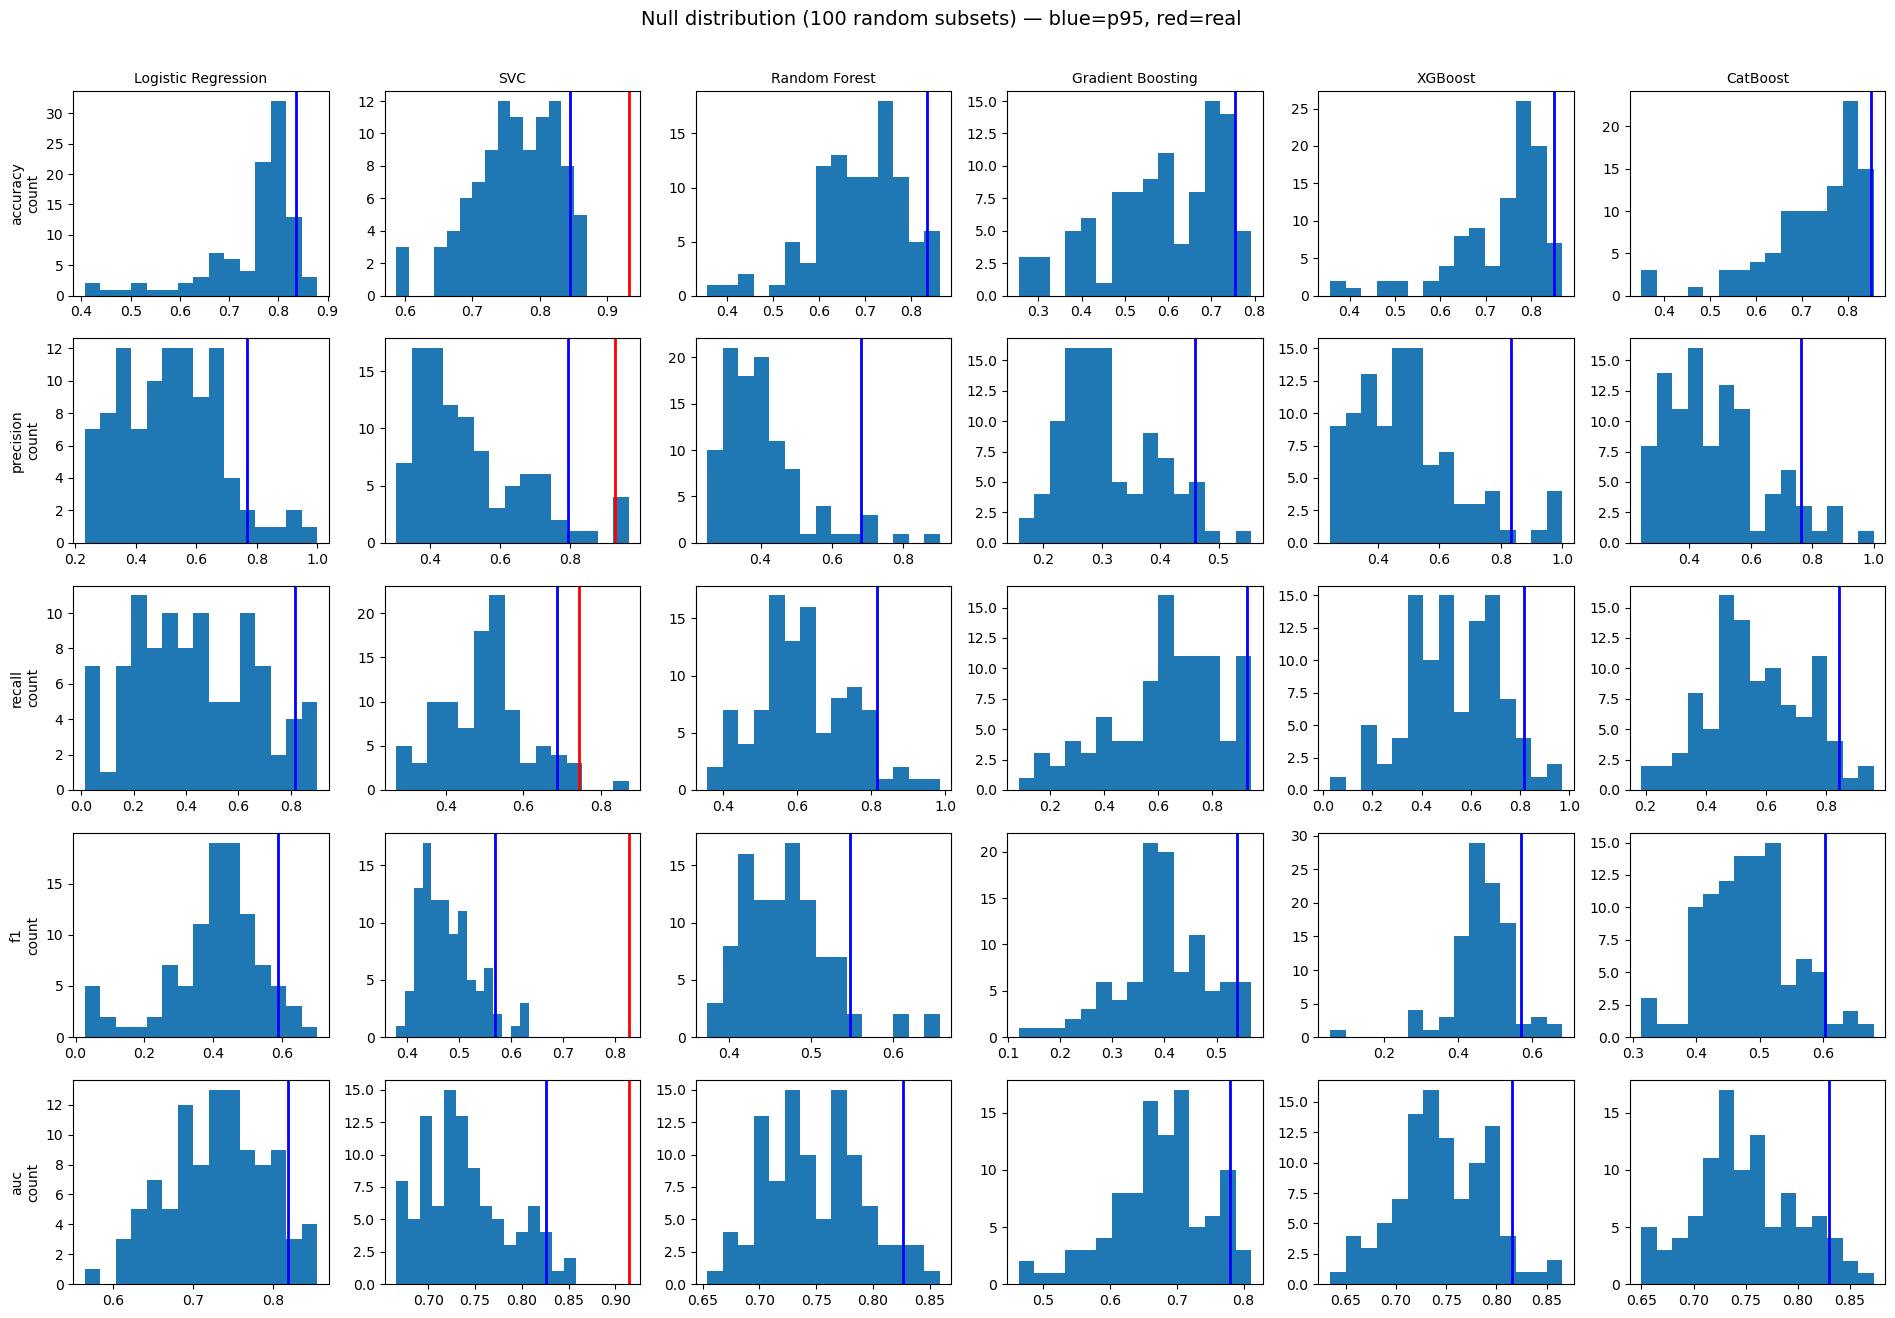

In [13]:
plot_single_compact_figure_all_metrics(
    results_df=results_df,
    p95=p95,
    real_scores_df=real_scores_df,
    metrics=metrics,
    bins=15,
    save_path=None  # oppure "plots/ALL_METRICS.png"
)

df_train shape: (95, 862)
df_test  shape: (322, 862)
Geni da rimuovere (presenti nel train): 12
Geni da rimuovere (presenti nel test):  12
Geni rimanenti dopo rimozione + intersezione train/test: 849

AUC computed rows: 6000
NaN AUC count: 0

===== Empirical p-values (one-sided) =====
                 model  p_emp_one_sided  n_null
0  Logistic Regression         0.000999    1000
1                  SVC         0.000999    1000
2        Random Forest         0.000999    1000
3    Gradient Boosting         0.001998    1000
4              XGBoost         0.002997    1000
5             CatBoost         0.001998    1000

===== 95° percentile AUC (1000 random subsets) =====
model
CatBoost               0.839467
Gradient Boosting      0.788111
Logistic Regression    0.829810
Random Forest          0.824613
SVC                    0.836638
XGBoost                0.831066
Name: auc, dtype: float64


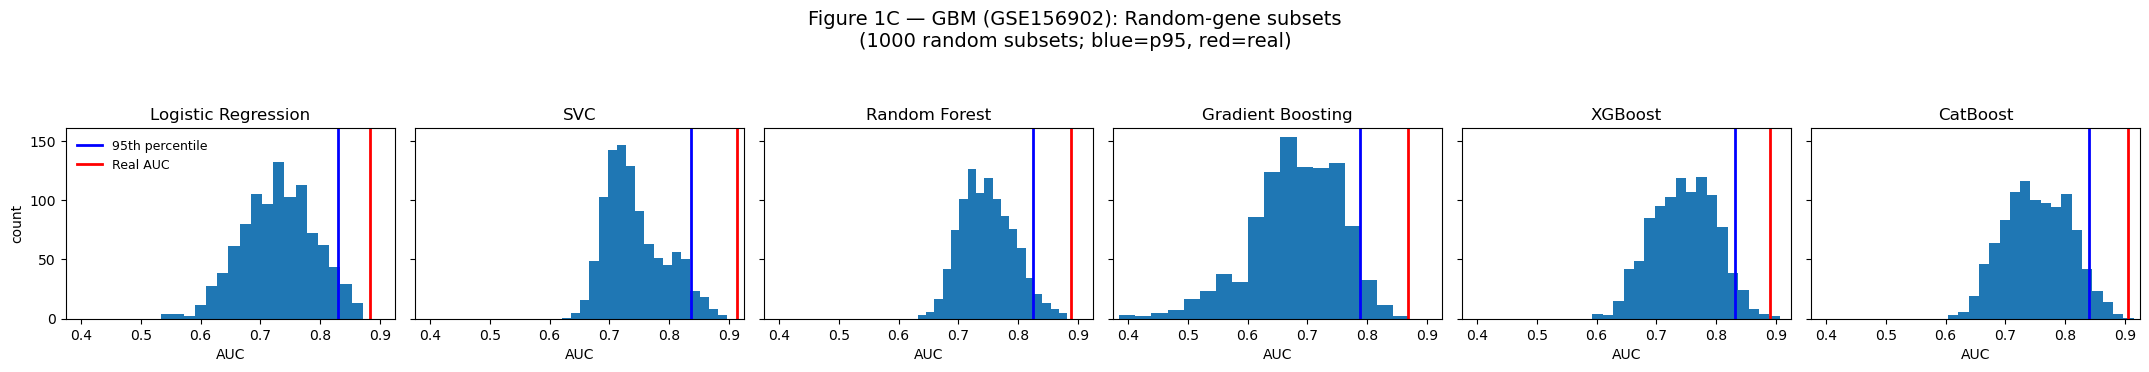

In [19]:
# ============================================================
# FIGURE 1C — Random-gene control (GBM GSE156902)
# - 1000 random gene subsets -> empirical NULL distribution of AUC
# - 95th percentile (BLUE line)
# - manual "real" AUC per classifier (RED line) via a table you fill
# - 1 row × 6 plots (LR, SVC, RF, GB, XGB, CAT)
# ============================================================

# =========================
# Packages
# =========================
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

import sys
sys.path.append("__HandmadePackages__")

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt


# =========================
# Config
# =========================
RANDOM_SEED = 42
N_REPEATS = 1000
N_GENES = 29
rng = np.random.default_rng(RANDOM_SEED)

# If you want deterministic model internals too (where possible)
MODEL_RANDOM_STATE = 42

# Plot settings
BINS = 18
SAVE_FIG = False
#SAVE_PATH = "Figure_1C_AUC_random_genes_GBM_GSE156902.png"


# =========================
# Load data
# =========================
df_train = pd.read_csv("train_degs_gbm_156902.csv")
df_test  = pd.read_csv("test_degs_gbm_156902.csv")

print(f"df_train shape: {df_train.shape}")
print(f"df_test  shape: {df_test.shape}")

X_train_full = df_train.iloc[:, :-1]
y_train = df_train.iloc[:, -1]

X_test_full = df_test.iloc[:, :-1]
y_test = df_test.iloc[:, -1]


# =========================
# Remove genes from intersection file
# =========================
# (use your file as in your script)
da_rimuovere = pd.read_csv("test_intersection_gbm_156902.csv")

remove_genes = da_rimuovere.columns[:-1].tolist()
remove_set = set(remove_genes)

to_drop_train = sorted(list(set(X_train_full.columns).intersection(remove_set)))
to_drop_test  = sorted(list(set(X_test_full.columns).intersection(remove_set)))

print(f"Geni da rimuovere (presenti nel train): {len(to_drop_train)}")
print(f"Geni da rimuovere (presenti nel test):  {len(to_drop_test)}")

X_train_full = X_train_full.drop(columns=to_drop_train, errors="ignore")
X_test_full  = X_test_full.drop(columns=to_drop_test, errors="ignore")

# keep only common cols
common_cols = sorted(list(set(X_train_full.columns).intersection(set(X_test_full.columns))))
X_train_full = X_train_full[common_cols]
X_test_full  = X_test_full[common_cols]

gene_cols = common_cols
print(f"Geni rimanenti dopo rimozione + intersezione train/test: {len(gene_cols)}")

if len(gene_cols) < N_GENES:
    raise ValueError(f"Dopo la rimozione restano {len(gene_cols)} geni, ma ne servono {N_GENES}.")


# =========================
# Helper: score continuo per AUC
# =========================
def get_y_score(model, X):
    """
    Returns a continuous score for AUC:
    - predict_proba[:,1] if available
    - decision_function if available
    - None otherwise
    """
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        return proba[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return None


# =========================
# Models
# =========================
def make_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=2000),
        # decision_function available -> ok for AUC without probability=True
        "SVC": SVC(kernel="rbf", C=1.0, gamma="scale", probability=False),
        "Random Forest": RandomForestClassifier(
            n_estimators=500, max_depth=None, random_state=MODEL_RANDOM_STATE
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            learning_rate=0.05, n_estimators=500, max_depth=10, random_state=MODEL_RANDOM_STATE
        ),
        "XGBoost": XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=10,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=MODEL_RANDOM_STATE,
            eval_metric="logloss"
        ),
        "CatBoost": CatBoostClassifier(
            iterations=500,
            learning_rate=0.05,
            depth=4,
            verbose=False,
            random_state=MODEL_RANDOM_STATE
        )
    }


# ============================================================
# 🔴 INSERT HERE YOUR REAL AUC VALUES (manual)
# Put np.nan if not available
# ============================================================
real_auc_df = pd.DataFrame([
    {"model": "Logistic Regression", "auc_real": 0.883},
    {"model": "SVC",                 "auc_real": 0.914},   # <-- example from your message
    {"model": "Random Forest",       "auc_real": 0.888},
    {"model": "Gradient Boosting",   "auc_real": 0.869},
    {"model": "XGBoost",             "auc_real": 0.891},
    {"model": "CatBoost",            "auc_real": 0.905},
])


# =========================
# Loop: 1000 random subsets -> AUC distribution
# =========================
rows = []

model_order = list(make_models().keys())  # fixed order for plotting

for rep in range(N_REPEATS):
    selected_genes = rng.choice(gene_cols, size=N_GENES, replace=False).tolist()

    X_train = X_train_full[selected_genes]
    X_test  = X_test_full[selected_genes]

    models = make_models()

    for model_name in model_order:
        model = models[model_name]
        model.fit(X_train, y_train)

        y_score = get_y_score(model, X_test)

        # AUC may fail if y_score is None or if y_test has 1 class (rare)
        try:
            auc = roc_auc_score(y_test, y_score) if y_score is not None else np.nan
        except Exception:
            auc = np.nan

        rows.append({
            "repeat": rep,
            "model": model_name,
            "auc": float(auc) if auc is not None else np.nan
        })

results_auc_df = pd.DataFrame(rows)

print("\nAUC computed rows:", results_auc_df.shape[0])
print("NaN AUC count:", int(results_auc_df["auc"].isna().sum()))

# =========================
# Empirical p-values (one-sided)
# =========================
real_idx = real_auc_df.set_index("model")["auc_real"]

pvals = []
for model in model_order:
    vals = results_auc_df.loc[results_auc_df["model"] == model, "auc"].dropna().values
    real_val = real_idx.get(model, np.nan)

    if np.isnan(real_val) or len(vals) == 0:
        p_emp = np.nan
    else:
        n = len(vals)
        p_emp = (1 + np.sum(vals >= real_val)) / (1 + n)  # one-sided (greater)

    pvals.append({"model": model, "p_emp_one_sided": p_emp, "n_null": len(vals)})

pvals_df = pd.DataFrame(pvals)
print("\n===== Empirical p-values (one-sided) =====")
print(pvals_df)

# =========================
# 95th percentile by model
# =========================
p95_auc = results_auc_df.groupby("model")["auc"].quantile(0.95)

print("\n===== 95° percentile AUC (1000 random subsets) =====")
print(p95_auc)


# =========================
# Plot: 1 row × 6 plots
# =========================
def plot_figure_1c_auc(results_auc_df, p95_auc, real_auc_df, model_order, bins=18,
                      title="Figure 1C — Random-gene control (AUC)",
                      save_fig=False, save_path="Figure_1C.png"):
    real_idx = real_auc_df.set_index("model")

    n_models = len(model_order)
    fig, axes = plt.subplots(1, n_models, figsize=(3.6 * n_models, 3.4), sharey=True)
    if n_models == 1:
        axes = [axes]

    # global x-limits (optional): makes panels comparable
    # global x-limits INCLUDING real values
    global_vals = results_auc_df["auc"].dropna().values
    real_vals = real_auc_df["auc_real"].dropna().values

    if len(global_vals) > 0 or len(real_vals) > 0:
        all_vals = np.concatenate([global_vals, real_vals])

        x_min = float(np.min(all_vals))
        x_max = float(np.max(all_vals))

        pad = 0.02 * (x_max - x_min) if x_max > x_min else 0.02
        xlim = (max(0.0, x_min - pad), min(1.0, x_max + pad))
    else:
        xlim = (0.0, 1.0)

    for i, model in enumerate(model_order):
        ax = axes[i]
        vals = results_auc_df.loc[results_auc_df["model"] == model, "auc"].dropna().values

        if len(vals) == 0:
            ax.set_title(model)
            ax.text(0.5, 0.5, "NO DATA", ha="center", va="center")
            ax.set_xlim(*xlim)
            continue

        thr95 = float(p95_auc.loc[model])

        ax.hist(vals, bins=bins)
        ax.axvline(thr95, color="blue", linewidth=2, label="95th percentile")

        real_val = np.nan
        if model in real_idx.index:
            real_val = real_idx.loc[model, "auc_real"]

        if not pd.isna(real_val):
            ax.axvline(float(real_val), color="red", linewidth=2, label="Real AUC")

        ax.set_title(model)
        ax.set_xlabel("AUC")
        ax.set_xlim(*xlim)

        if i == 0:
            ax.set_ylabel("count")
            ax.legend(loc="upper left", frameon=False, fontsize=9)

    fig.suptitle(title + "\n(1000 random subsets; blue=p95, red=real)", y=1.08, fontsize=14)
    fig.tight_layout()

    if save_fig:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


plot_figure_1c_auc(
    results_auc_df=results_auc_df,
    p95_auc=p95_auc,
    real_auc_df=real_auc_df,
    model_order=model_order,
    bins=BINS,
    title="Figure 1C — GBM (GSE156902): Random-gene subsets",
    save_fig=SAVE_FIG,
    #save_path=SAVE_PATH
)

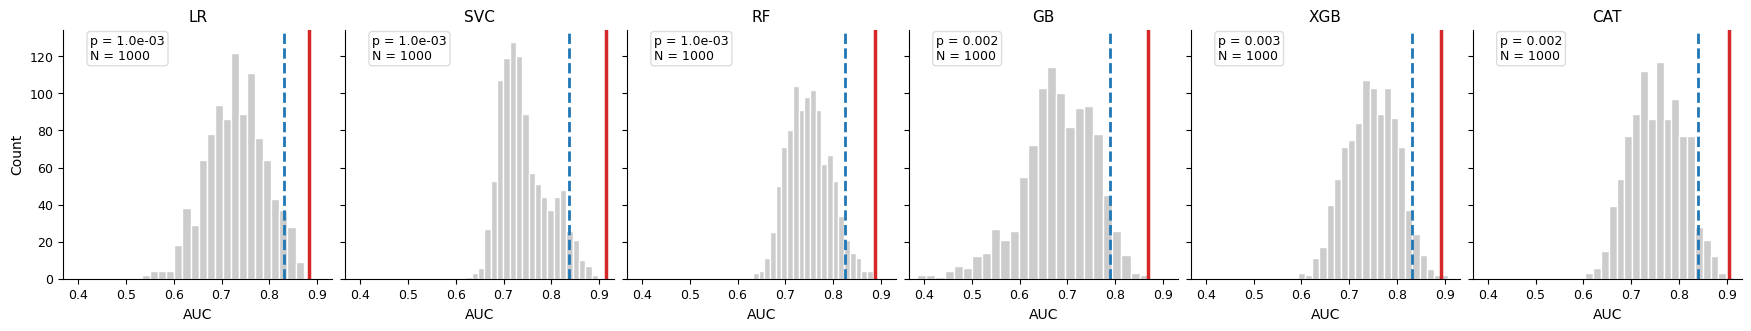

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _fd_bins(x):
    """Freedman–Diaconis rule for histogram bins (robust, publication-friendly)."""
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.size < 2:
        return 10
    q25, q75 = np.percentile(x, [25, 75])
    iqr = q75 - q25
    if iqr == 0:
        return 12
    bin_width = 2 * iqr * (x.size ** (-1 / 3))
    if bin_width <= 0:
        return 12
    n_bins = int(np.ceil((x.max() - x.min()) / bin_width))
    return int(np.clip(n_bins, 8, 30))


def plot_figure_1c_auc_pub(
    results_auc_df,
    p95_auc,
    real_auc_df,
    model_order,
    save_path=None,   # es: "Figure1C.png" oppure "Figure1C.pdf"
    dpi=600
):
    """
    1×N panels: histogram of null AUCs (random gene subsets) per model.
    Blue dashed line: 95th percentile of null.
    Red solid line: real AUC.
    Adds empirical one-sided p-value in each panel:
        p = (1 + #{null >= real}) / (1 + N_null)
    """

    # --- prepare lookups ---
    real_idx = real_auc_df.set_index("model")

    # --- global xlim INCLUDING real values ---
    null_vals = results_auc_df["auc"].dropna().values
    real_vals = real_auc_df["auc_real"].dropna().values
    all_vals = np.concatenate([null_vals, real_vals]) if (len(null_vals) + len(real_vals)) > 0 else np.array([0, 1])

    x_min = float(np.min(all_vals))
    x_max = float(np.max(all_vals))
    pad = 0.03 * (x_max - x_min) if x_max > x_min else 0.03
    xlim = (max(0.0, x_min - pad), min(1.0, x_max + pad))

    # --- nice short labels for panels ---
    short = {
        "Logistic Regression": "LR",
        "SVC": "SVC",
        "Random Forest": "RF",
        "Gradient Boosting": "GB",
        "XGBoost": "XGB",
        "CatBoost": "CAT",
    }

    # --- empirical p-values (one-sided; greater is better) ---
    # p = (1 + #{null >= real}) / (1 + N_null)
    real_series = real_auc_df.set_index("model")["auc_real"]

    p_emp = {}
    n_null = {}
    for m in model_order:
        null_m = results_auc_df.loc[results_auc_df["model"] == m, "auc"].dropna().values
        rv = real_series.get(m, np.nan)

        n_null[m] = int(len(null_m))
        if np.isnan(rv) or len(null_m) == 0:
            p_emp[m] = np.nan
        else:
            p_emp[m] = (1.0 + float(np.sum(null_m >= rv))) / (1.0 + float(len(null_m)))

    def _fmt_p(p):
        if not np.isfinite(p):
            return "p = NA"
        if p < 1e-3:
            return f"p = {p:.1e}"
        return f"p = {p:.3f}"

    # --- build figure ---
    n = len(model_order)
    fig, axes = plt.subplots(
        1, n,
        figsize=(2.9 * n, 3.2),
        sharey=True,
        constrained_layout=True
    )
    if n == 1:
        axes = [axes]

    # --- plot each panel ---
    for i, model in enumerate(model_order):
        ax = axes[i]
        vals = results_auc_df.loc[results_auc_df["model"] == model, "auc"].dropna().values

        # choose bins automatically (per-model) but within nice range
        bins = _fd_bins(vals) if len(vals) else 10

        ax.hist(vals, bins=bins, color="0.8", edgecolor="white")

        # p95
        thr95 = float(p95_auc.loc[model])
        ax.axvline(
            thr95,
            color="#1f77b4",
            linestyle="--",
            linewidth=2,
            label="95th percentile (random)" if i == 0 else None
        )

        # real
        real_val = real_idx.loc[model, "auc_real"] if model in real_idx.index else np.nan
        if not pd.isna(real_val):
            ax.axvline(
                float(real_val),
                color="#d62728",
                linewidth=2.5,
                label="Real AUC" if i == 0 else None
            )

        # --- add empirical p-value (and N) as an in-panel annotation ---
        txt = f"{_fmt_p(p_emp[model])}\nN = {n_null[model]}"
        ax.text(
            0.1, 0.98, txt,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=9,
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="0.85",
                alpha=0.9
            )
        )

        ax.set_title(short.get(model, model), fontsize=11, pad=6)
        ax.set_xlim(*xlim)
        ax.set_xlabel("AUC", fontsize=10)
        if i == 0:
            ax.set_ylabel("Count", fontsize=10)

        # cleaner axes
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="both", labelsize=9)



    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()


# USAGE:
plot_figure_1c_auc_pub(
     results_auc_df=results_auc_df,
     p95_auc=p95_auc,
     real_auc_df=real_auc_df,
     model_order=model_order,
     save_path="Figure1C_AUC.png",
     dpi=600
)

C:\Users\stefa\AppData\Local\Temp\ipykernel_21472\371569903.py:119: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(


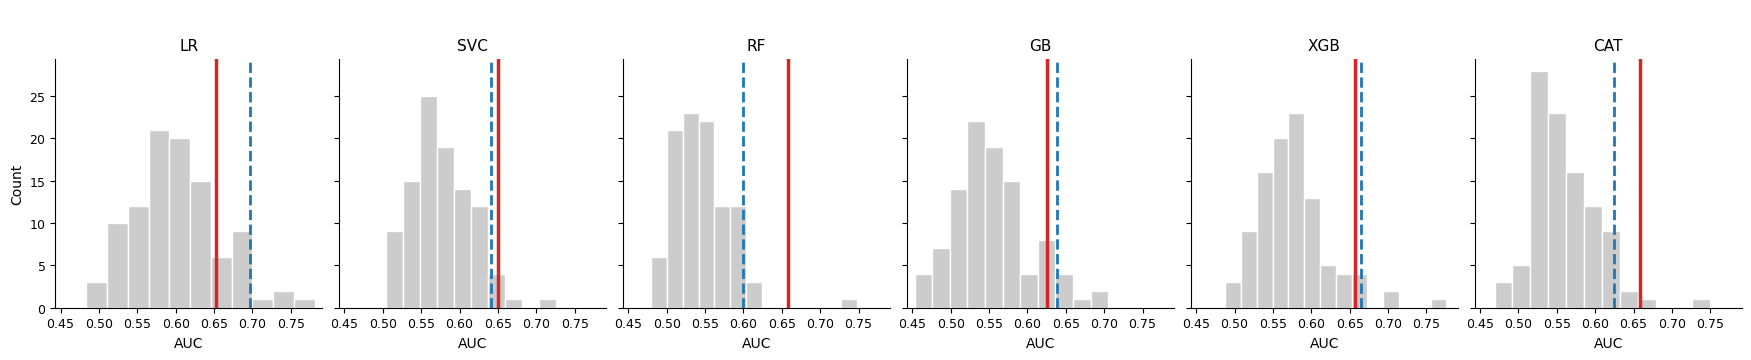

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _fd_bins(x):
    """Freedman–Diaconis rule for histogram bins (robust, publication-friendly)."""
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.size < 2:
        return 10
    q25, q75 = np.percentile(x, [25, 75])
    iqr = q75 - q25
    if iqr == 0:
        return 12
    bin_width = 2 * iqr * (x.size ** (-1/3))
    if bin_width <= 0:
        return 12
    n_bins = int(np.ceil((x.max() - x.min()) / bin_width))
    return int(np.clip(n_bins, 8, 30))


def plot_figure_1c_auc_pub(
    results_auc_df,
    p95_auc,
    real_auc_df,
    model_order,
    #title="Figure 1C — GBM (GSE156902): random-gene subsets",
    #subtitle="1000 random subsets; blue = 95th percentile, red = real",
    save_path=None,   # es: "Figure1C.png" oppure "Figure1C.pdf"
    dpi=600
):
    # --- prepare lookups ---
    real_idx = real_auc_df.set_index("model")

    # --- global xlim INCLUDING real values ---
    null_vals = results_auc_df["auc"].dropna().values
    real_vals = real_auc_df["auc_real"].dropna().values
    all_vals = np.concatenate([null_vals, real_vals]) if (len(null_vals) + len(real_vals)) > 0 else np.array([0, 1])

    x_min = float(np.min(all_vals))
    x_max = float(np.max(all_vals))
    pad = 0.03 * (x_max - x_min) if x_max > x_min else 0.03
    xlim = (max(0.0, x_min - pad), min(1.0, x_max + pad))

    # --- nice short labels for panels ---
    short = {
        "Logistic Regression": "LR",
        "SVC": "SVC",
        "Random Forest": "RF",
        "Gradient Boosting": "GB",
        "XGBoost": "XGB",
        "CatBoost": "CAT",
    }

    # --- build figure ---
    n = len(model_order)
    fig, axes = plt.subplots(
    1, n,
    figsize=(2.9 * n, 3.2),
    sharey=True,
    constrained_layout=True
    )

    if n == 1:
        axes = [axes]

    # --- plot each panel ---
    for i, model in enumerate(model_order):
        ax = axes[i]
        vals = results_auc_df.loc[results_auc_df["model"] == model, "auc"].dropna().values

        # choose bins automatically (per-model) but within nice range
        bins = _fd_bins(vals) if len(vals) else 10

        ax.hist(vals, bins=bins,color="0.8", edgecolor="white")     # più pulito a 600 dpi)

        # p95
        thr95 = float(p95_auc.loc[model])
        ax.axvline(
            thr95,
            color="#1f77b4",      # blu scientifico
            linestyle="--",      # tratteggiata = soglia
            linewidth=2
        )

        # real
        real_val = real_idx.loc[model, "auc_real"] if model in real_idx.index else np.nan
        if not pd.isna(real_val):
            ax.axvline(
            float(real_val),
            color="#d62728",      # rosso elegante
            linewidth=2.5        # leggermente più spessa
        )

        ax.set_title(short.get(model, model), fontsize=11, pad=6)
        ax.set_xlim(*xlim)
        ax.set_xlabel("AUC", fontsize=10)

        if i == 0:
            ax.set_ylabel("Count", fontsize=10)

        # cleaner axes
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="both", labelsize=9)

    # --- global title ---
    #fig.suptitle(title, fontsize=13, y=1.08)
    #fig.text(0.5, 1.02, subtitle, ha="center", fontsize=11)

    # --- single legend (custom handles) ---
    from matplotlib.lines import Line2D
    #handles = [
    #Line2D([0], [0], color="#1f77b4", lw=2, linestyle="--",
    #       label="95th percentile (random)"),
    #Line2D([0], [0], color="#d62728", lw=2.5,
    #       label="S AUC"),
    #]
    fig.legend(
    #handles=handles,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.1),   # più in alto
    fontsize=10
    )


    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()

plot_figure_1c_auc_pub(
    results_auc_df=results_auc_df,
    p95_auc=p95_auc,
    real_auc_df=real_auc_df,
    model_order=model_order,
    save_path="Figure1C_AUC.png"  
)